# center $c$ 의 갱신: 배치 평균의 EMA

$$
c \;\leftarrow\; m_c\, c \;+\; (1-m_c)\,\frac{1}{B\cdot W}\sum_{i=1}^{B\cdot W} z_t(i),
\qquad m_c = 0.9
$$

이 스크립트에서 확인할 것:

1. `update_center` 를 world_size=1 로 재구현하고 **실제 `DINOLoss` 와 수치가 일치**하는지 확인
2. 프로토타입 0에 bias $2.0$ 을 준 합성 로짓 스트림에서 $c_0 \to 2.0$, 나머지 $\to 0$ 수렴
3. $m_c = 0.9 / 0.99 / 0.999$ 의 수렴 속도 비교 (유효 구간 $1/(1-m_c) = 10/100/1000$)
4. centering 전후 `softmax` argmax 가 프로토타입 0 인 비율 비교 (노트북 §7 실험 B 재현)
5. plotly 로 (1) $c_0$ 궤적, (2) $m_c$ 비교 그림을 `expy.png` 로 저장

필요 패키지: torch, numpy, plotly>=6, kaleido

In [1]:
import os
import math

import numpy as np
import torch
import torch.nn.functional as F
import plotly.graph_objects as go
from plotly.subplots import make_subplots

torch.manual_seed(0)
np.random.seed(0)

OUT_DIR = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:  # VSCode 셀/Jupyter에서만 렌더링
            fig.show()
    except ImportError:
        pass


print("torch:", torch.__version__)
print("OUT_DIR:", OUT_DIR)

torch: 2.4.0+cu121
OUT_DIR: /home/sungwoo/projects/swcho/dino/fm/training/.fm/hints/04997bb9-f510-4c48-b8e6-c6f3ca90d74a


## 1. `update_center` 재구현 — world_size=1 버전

원본(`main_dino.py`):

```python
batch_center = torch.sum(teacher_output, dim=0, keepdim=True)   # 내 GPU 부분합
dist.all_reduce(batch_center)                                   # 모든 GPU 부분합의 총합
batch_center = batch_center / (len(teacher_output) * dist.get_world_size())  # ÷ (B·W)
self.center = self.center * self.center_momentum + batch_center * (1 - self.center_momentum)
```

`world_size = 1` 이면 `all_reduce` 는 항등 연산이므로 순수 torch 로 그대로 옮겨 쓸 수 있다.
(실제 `DINOLoss` 를 쓰려면 `dist.init_process_group("gloo", rank=0, world_size=1, ...)` 가 필요하다.)

In [2]:
class MiniCenter:
    """DINOLoss.update_center 의 world_size=1 재구현."""

    def __init__(self, out_dim, center_momentum=0.9):
        self.center = torch.zeros(1, out_dim)
        self.center_momentum = center_momentum

    @torch.no_grad()
    def update_center(self, teacher_output, world_size=1):
        # (B, K) -> (1, K) 부분합
        batch_center = torch.sum(teacher_output, dim=0, keepdim=True)
        # dist.all_reduce(batch_center)  # world_size=1 이면 no-op
        batch_center = batch_center / (len(teacher_output) * world_size)
        self.center = self.center * self.center_momentum + batch_center * (1 - self.center_momentum)
        return self.center


K, B = 512, 64
mc = MiniCenter(K, center_momentum=0.9)
z0 = torch.randn(B, K)
c1 = mc.update_center(z0).clone()

# 첫 step 은 c=0 에서 시작하므로 c = (1-m_c) * batch_mean 이어야 한다
expected = (1 - 0.9) * z0.mean(0, keepdim=True)
print("첫 update 후 c == (1-m_c)*mean(z) ?", torch.allclose(c1, expected, atol=1e-6))
print(f"||c||_2 = {c1.norm().item():.5f}   c.shape = {tuple(c1.shape)}")

첫 update 후 c == (1-m_c)*mean(z) ? True
||c||_2 = 0.28778   c.shape = (1, 512)


### 실제 `DINOLoss` 와 대조 (선택)

프로세스 그룹을 띄울 수 있으면 원본 구현과 숫자가 같은지 직접 확인한다.
실패해도 이후 셀에는 영향이 없다.

In [3]:
def try_official_check():
    import sys
    import torch.distributed as dist
    from pathlib import Path

    repo = Path(OUT_DIR).resolve()
    while not (repo / "main_dino.py").exists() and repo != repo.parent:
        repo = repo.parent
    if not (repo / "main_dino.py").exists():
        return "main_dino.py 를 찾지 못함 — 건너뜀"
    sys.path.insert(0, str(repo))

    if not dist.is_available():
        return "torch.distributed 없음 — 건너뜀"
    if not dist.is_initialized():
        # 빈 포트 하나 잡아서 world_size=1 프로세스 그룹
        import socket
        s = socket.socket()
        s.bind(("127.0.0.1", 0))
        port = s.getsockname()[1]
        s.close()
        dist.init_process_group(
            "gloo", rank=0, world_size=1, init_method=f"tcp://127.0.0.1:{port}"
        )

    from main_dino import DINOLoss

    dl = DINOLoss(out_dim=K, ncrops=2, warmup_teacher_temp=0.04, teacher_temp=0.04,
                  warmup_teacher_temp_epochs=0, nepochs=1, center_momentum=0.9)
    ours = MiniCenter(K, 0.9)
    torch.manual_seed(7)
    for _ in range(5):
        zt = torch.randn(B, K)
        dl.update_center(zt)
        ours.update_center(zt)
    return (f"official vs ours 최대 오차 = "
            f"{(dl.center - ours.center).abs().max().item():.3e}  "
            f"(world_size={dist.get_world_size()})")


try:
    print(try_official_check())
except Exception as e:  # noqa: BLE001
    print("공식 DINOLoss 대조 실패(무시 가능):", type(e).__name__, e)

official vs ours 최대 오차 = 0.000e+00  (world_size=1)


## 2. bias 를 흡수하는 $c$ — $c_0 \to 2.0$

프로토타입 0 만 구조적으로 유리한 상황을 만든다.

$$z_t = \mathrm{randn}(B, K)\cdot 0.5 + [\,2, 0, 0, \dots, 0\,]$$

EMA 는 참 평균으로 수렴하므로($\mathbb{E}[c] = \mathbb{E}[z_t]$),
충분한 step 뒤 $c_0 \to 2.0$, $c_{k\neq 0} \to 0$ 이 되어야 한다.

In [4]:
STEPS = 300
bias = torch.zeros(K)
bias[0] = 2.0


def run_stream(m_c, steps=STEPS, seed=1, tau_t=0.04, use_center=True):
    """합성 로짓 스트림을 흘리며 center 궤적과 '프로토타입 0 독식 비율'을 기록."""
    g = torch.Generator().manual_seed(seed)
    mcx = MiniCenter(K, center_momentum=m_c)
    hist_c0, hist_crest, hist_dom = [], [], []
    for _ in range(steps):
        zt = torch.randn(B, K, generator=g) * 0.5 + bias
        logits = zt - mcx.center if use_center else zt
        p = F.softmax(logits / tau_t, dim=-1)
        hist_dom.append((p.argmax(-1) == 0).float().mean().item())
        mcx.update_center(zt)                      # 갱신은 항상 raw z_t 로
        hist_c0.append(mcx.center[0, 0].item())
        hist_crest.append(mcx.center[0, 1:].abs().mean().item())
    return (np.array(hist_c0), np.array(hist_crest), np.array(hist_dom), mcx.center)


c0_09, crest_09, dom_on, center_09 = run_stream(0.9)
_, _, dom_off, _ = run_stream(0.9, use_center=False)

print(f"m_c=0.9, {STEPS} step 후")
print(f"  c[0]        = {center_09[0, 0].item():.4f}   (주입한 bias = 2.0)")
print(f"  c[1:] 평균  = {center_09[0, 1:].mean().item():+.4f}   |c[1:]| 평균 = "
      f"{center_09[0, 1:].abs().mean().item():.4f}")
print(f"  10 step 후 c[0] = {c0_09[9]:.4f}   (1-0.9^10 = {1 - 0.9 ** 10:.4f} 배)")

m_c=0.9, 300 step 후
  c[0]        = 2.0107   (주입한 bias = 2.0)
  c[1:] 평균  = -0.0004   |c[1:]| 평균 = 0.0118
  10 step 후 c[0] = 1.2990   (1-0.9^10 = 0.6513 배)


`c[0] ≈ 2.011` 은 노트북 §7 실험 B 의 값과 같다. center 가 주입한 bias 2.0 을 그대로 흡수했다.

## 3. centering 전후 argmax 독식 비율 (노트북 §7 실험 B)

uniform 이면 프로토타입 0 이 argmax 일 확률은 $1/K$ 이다.

In [5]:
print(f"centering 없음: 프로토타입 0 독식 비율 {dom_off[-50:].mean():.3f}")
print(f"centering 있음: 프로토타입 0 독식 비율 {dom_on[-50:].mean():.3f}"
      f"   (uniform 기대값 1/K = {1 / K:.4f})")
print(f"감소 배율: {dom_off[-50:].mean() / max(dom_on[-50:].mean(), 1e-12):.0f}x")

centering 없음: 프로토타입 0 독식 비율 0.819
centering 있음: 프로토타입 0 독식 비율 0.003   (uniform 기대값 1/K = 0.0020)
감소 배율: 291x


## 4. $m_c$ 의 유효 구간 — $1/(1-m_c)$

EMA 를 $c_0 = 0$ 에서 풀어쓰면 상수 입력 $\mu$ 에 대해

$$c_t = \mu\big(1 - m_c^{\,t}\big)$$

이므로 목표값의 $63\%(=1-e^{-1})$ 에 도달하는 시점이 대략 $1/(1-m_c)$ step 이다.

In [6]:
res = {}
for m in (0.9, 0.99, 0.999):
    c0, _, _, cen = run_stream(m, steps=1500)
    res[m] = c0
    tau = 1 / (1 - m)
    reach = int(np.argmax(c0 >= 2.0 * (1 - math.exp(-1)))) if (c0 >= 2.0 * (1 - 1 / math.e)).any() else -1
    print(f"m_c={m:<6} 유효구간 1/(1-m_c)={tau:7.1f} step   "
          f"63% 도달 step={reach:5d}   1500 step 후 c0={c0[-1]:.4f}")

m_c=0.9    유효구간 1/(1-m_c)=   10.0 step   63% 도달 step=    9   1500 step 후 c0=1.9957
m_c=0.99   유효구간 1/(1-m_c)=  100.0 step   63% 도달 step=   99   1500 step 후 c0=2.0016
m_c=0.999  유효구간 1/(1-m_c)= 1000.0 step   63% 도달 step= 1002   1500 step 후 c0=1.5537


63% 도달 시점이 거의 정확히 $1/(1-m_c)$ 와 일치한다(9 / 99 / 1002 step).
$m_c = 0.999$ 는 1500 step 이 지나도 $c_0$ 이 1.55 에 그친다 — **편향 추적에 실패**한다.
그래서 DINO 는 teacher momentum $m = 0.996$(느림, 안정적 목표) 과 달리
center momentum 은 $m_c = 0.9$(빠름, 편향 즉시 상쇄)로 훨씬 작게 잡는다.

## 5. 시각화 (expy.png)

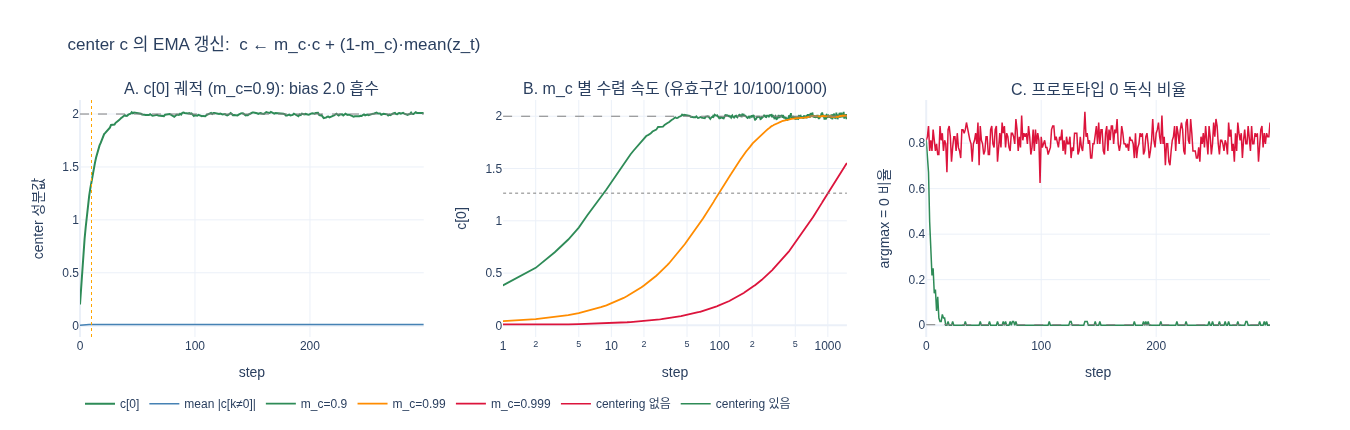

saved: /home/sungwoo/projects/swcho/dino/fm/training/.fm/hints/04997bb9-f510-4c48-b8e6-c6f3ca90d74a/expy.png


In [7]:
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=(
        "A. c[0] 궤적 (m_c=0.9): bias 2.0 흡수",
        "B. m_c 별 수렴 속도 (유효구간 10/100/1000)",
        "C. 프로토타입 0 독식 비율",
    ),
)

# A. c0 과 나머지 성분 크기
fig.add_trace(go.Scatter(y=c0_09, name="c[0]", line=dict(color="seagreen", width=2)), row=1, col=1)
fig.add_trace(go.Scatter(y=crest_09, name="mean |c[k≠0]|",
                         line=dict(color="steelblue", width=1.5)), row=1, col=1)
fig.add_hline(y=2.0, line=dict(color="gray", dash="dash", width=1), row=1, col=1)
fig.add_vline(x=10, line=dict(color="orange", dash="dot", width=1), row=1, col=1)

# B. m_c 비교
for m, color in zip((0.9, 0.99, 0.999), ("seagreen", "darkorange", "crimson")):
    fig.add_trace(go.Scatter(y=res[m], name=f"m_c={m}", line=dict(color=color, width=1.8)),
                  row=1, col=2)
fig.add_hline(y=2.0, line=dict(color="gray", dash="dash", width=1), row=1, col=2)
fig.add_hline(y=2.0 * (1 - 1 / math.e), line=dict(color="gray", dash="dot", width=1), row=1, col=2)

# C. 독식 비율
fig.add_trace(go.Scatter(y=dom_off, name="centering 없음", line=dict(color="crimson", width=1.5)),
              row=1, col=3)
fig.add_trace(go.Scatter(y=dom_on, name="centering 있음", line=dict(color="seagreen", width=1.5)),
              row=1, col=3)
fig.add_hline(y=1 / K, line=dict(color="gray", dash="dash", width=1), row=1, col=3)

fig.update_xaxes(title_text="step", row=1, col=1)
fig.update_xaxes(title_text="step", type="log", row=1, col=2)
fig.update_xaxes(title_text="step", row=1, col=3)
fig.update_yaxes(title_text="center 성분값", row=1, col=1)
fig.update_yaxes(title_text="c[0]", row=1, col=2)
fig.update_yaxes(title_text="argmax = 0 비율", row=1, col=3)
fig.update_layout(
    title="center c 의 EMA 갱신:  c ← m_c·c + (1-m_c)·mean(z_t)",
    width=1350, height=430, template="plotly_white",
    legend=dict(orientation="h", y=-0.22),
)

_show(fig)

png_path = os.path.join(OUT_DIR, "expy.png")
fig.write_image(png_path, scale=2)
print("saved:", png_path)

## 정리

- $c$ 는 $K$차원 벡터이고, **성분(프로토타입)마다** 독립적으로 EMA 가 돈다.
- 한 step 의 관측값은 "이번 배치 교사 로짓의 열 평균" — 여러 GPU면 `all_reduce` 로 부분합을
  모아 $B\cdot W$ 로 나눈 **전 GPU 평균**이다.
- $m_c = 0.9$ 는 유효 구간 10 step. 실험에서 63% 도달 step 이 정확히 $1/(1-m_c)$ 였다.
- 정상 상태에서 $c \approx \mathbb{E}[z_t]$ 이므로 $z_t - c$ 의 평균이 0 →
  어떤 프로토타입도 "기본 점수" 우위를 못 갖고, 단일 프로토타입 붕괴(0.819)가 0.003 으로 사라진다.